In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
df.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [7]:
df["sex"] = df["sex"].map({"male": 0, "female":1})
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [8]:
df['smoker'] = df['smoker'].map({'yes':1 , 'no':0})
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [9]:
df = df.drop(columns = ['region'])
df

,age,sex,bmi,children,smoker,charges
0,19,1,27.900,0,1,16884.92400
1,18,0,33.770,1,0,1725.55230
2,28,0,33.000,3,0,4449.46200
3,33,0,22.705,0,0,21984.47061
4,32,0,28.880,0,0,3866.85520
...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830
1334,18,1,31.920,0,0,2205.98080
1335,18,1,36.850,0,0,1629.83350
1336,21,1,25.800,0,0,2007.94500


In [10]:
# Calculate the first and third quartiles
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
print(f'Q1 = {Q1:.2f}')
print(f'Q3 = {Q3:.2f}')
# Calculate the interquartile range (IQR)
IQR = Q3 - Q1
print(f'IQR = {IQR:.2f}')
# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Lower Bound = {lower_bound:.2f}')
print(f'Upper Bound = {upper_bound:.2f}')

Q1 = 27.00
Q3 = 51.00
IQR = 24.00
Lower Bound = -9.00
Upper Bound = 87.00


In [12]:
df['age'] 
outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]

print(f"Total rows: {len(df)}")
print(f"Outliers found or outliers rows: {len(outliers)}")

Total rows: 1338
Outliers found or outliers rows: 0


In [13]:
bmi_Q1 = df['bmi'].quantile(0.25)
bmi_Q3 = df['bmi'].quantile(0.75)
print(f'Q1 = {bmi_Q1:.2f}')
print(f'Q3 = {bmi_Q3:.2f}')

bmi_IQR = bmi_Q3 - bmi_Q1
print(f'IQR = {IQR:.2f}')

lower_bound1 = bmi_Q1 - 1.5 * bmi_IQR
upper_bound1 = bmi_Q3 + 1.5 * bmi_IQR
print(f'Lower Bound = {lower_bound:.2f}')
print(f'Upper Bound = {upper_bound:.2f}')

Q1 = 26.30
Q3 = 34.69
IQR = 24.00
Lower Bound = -9.00
Upper Bound = 87.00


In [14]:
outliers = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)]

print(f"Total rows: {len(df)}")
print(f"Outliers found or outliers rows: {len(outliers)}")

Total rows: 1338
Outliers found or outliers rows: 0


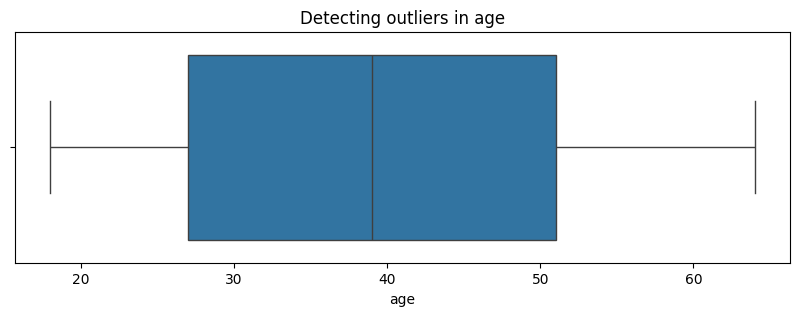

In [19]:
plt.figure(figsize=(10, 3)) #10 inches wide and 3 inches tall for the= canvas
sns.boxplot(x=df['age'])
plt.title(f'Detecting outliers in {'age'}')
plt.show()